In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install pandas pillow

In [2]:
!pip install pandas
!pip install opencv-python

In [4]:
!pip install tensorflow==2.12.0
!pip install keras

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 2.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 2.2 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 2.8 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 95.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 91.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 21.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: wrapt
    

In [6]:
!pip install -q datasets

In [7]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
# Import RandomFlip and RandomRotation from the preprocessing module
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D, LeakyReLU

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE = (299, 299) # resolution
directory = "/kaggle/input/tomato-dataset"
BATCH_SIZE = 128

train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)

validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)

Found 7091 files belonging to 4 classes.
Using 6382 files for training.
Found 7091 files belonging to 4 classes.
Using 709 files for validation.


In [9]:
class_names = train_dataset.class_names
class_names

['Tomato_Bacterial_spot',
 'Tomato_Late_blight',
 'Tomato__Target_Spot',
 'Tomato_healthy']

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


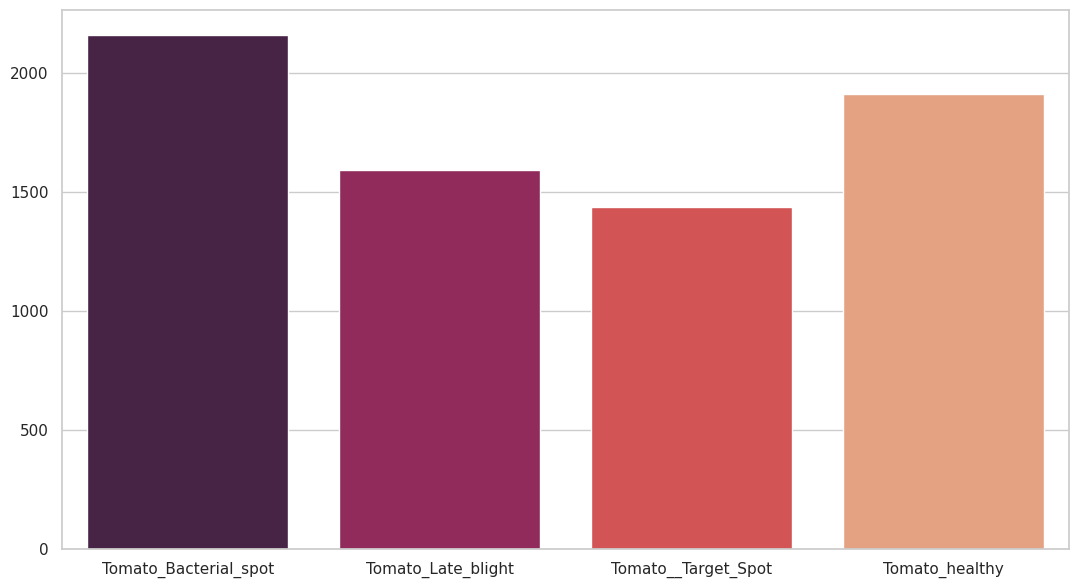

In [10]:
sns.set_theme(style="whitegrid")
Data_imbalance = []
for folder in os.listdir(directory):
    files = gb.glob(pathname=str(directory + "/" + folder +"/*.*"))
    Data_imbalance.append(len(files))
plt.figure(figsize=(13,7))
sns.barplot(x=['Tomato_Bacterial_spot',
 'Tomato_Late_blight',
 'Tomato__Target_Spot',
 'Tomato_healthy'], y=Data_imbalance, palette="rocket")
plt.show()

In [11]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)
weight_for_3 = (1 / Data_imbalance[3]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))
print('Weight for class 3: {:.2f}'.format(weight_for_3))

Weight for class 0: 0.82
Weight for class 1: 1.11
Weight for class 2: 1.24
Weight for class 3: 0.93


In [12]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])

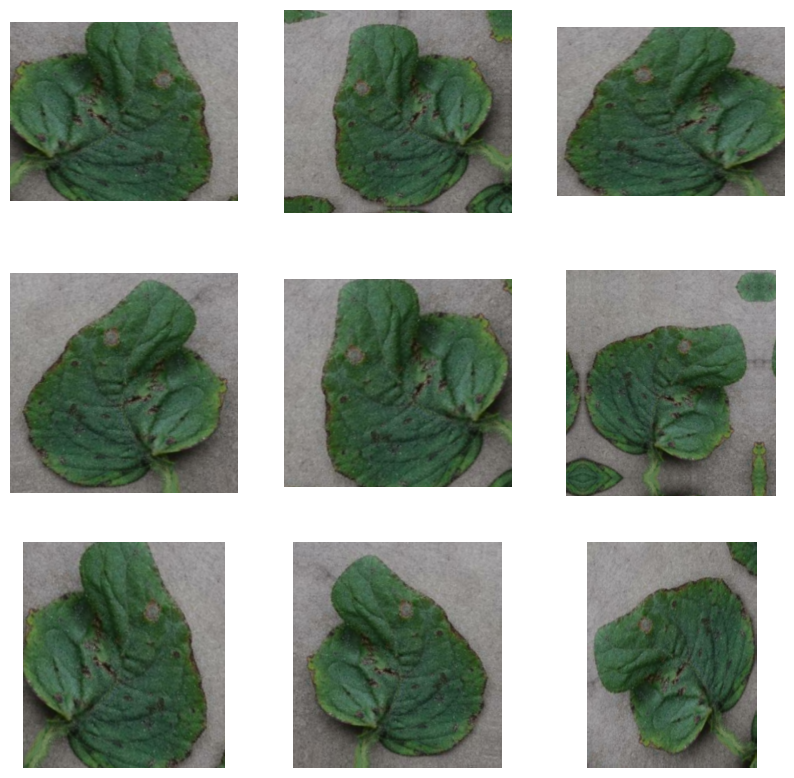

In [13]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')


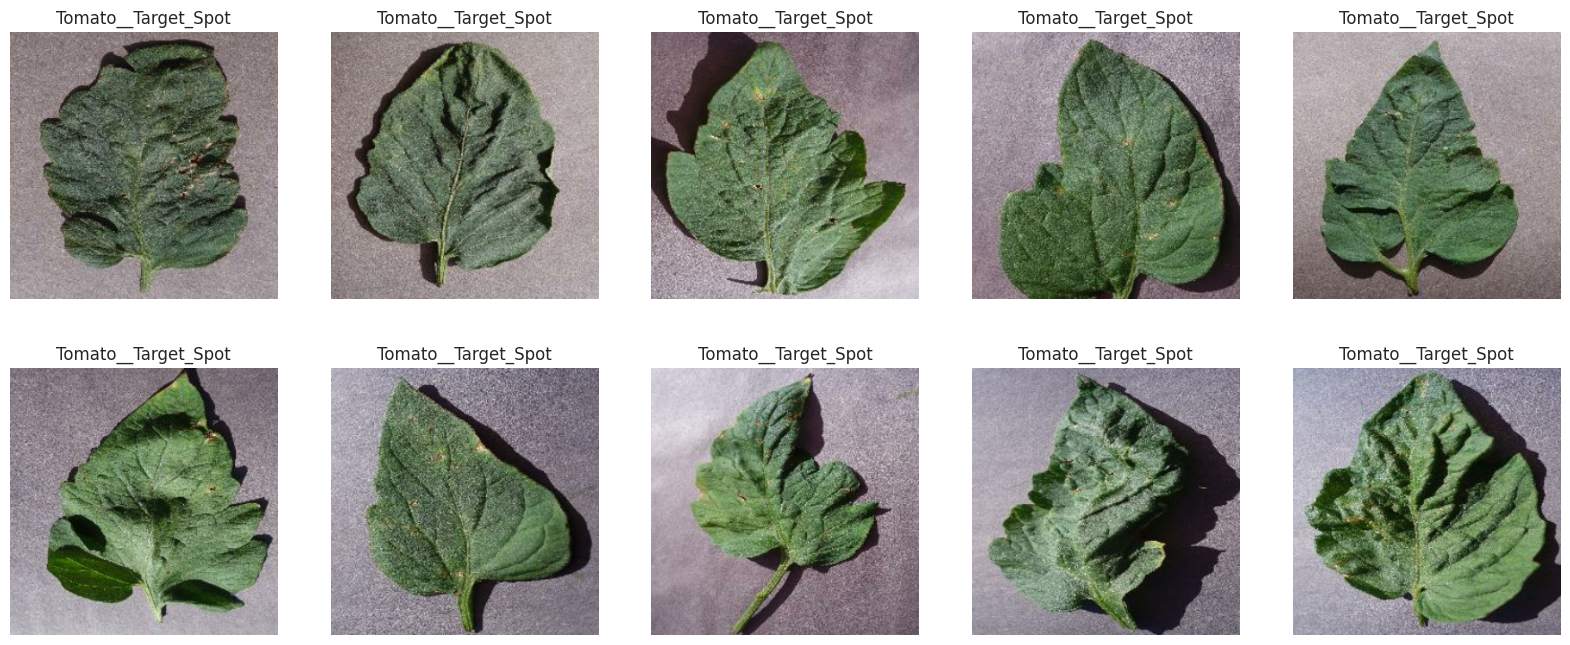

In [14]:
plt.figure(figsize=(20,8))
Tomato__Target_Spot = []
Tomato_Bacterial_spot= []
Tomato_Late_blight =[]


for images , labels in train_dataset.take(1):
    for i in range(100):
        if class_names[labels[i]] == "Tomato__Target_Spot":
            Tomato__Target_Spot.append(images[i].numpy().astype("uint8"))
        if  class_names[labels[i]] == "Tomato_Bacterial_spot":
            Tomato_Bacterial_spot.append(images[i].numpy().astype("uint8"))
        if  class_names[labels[i]] == "Tomato_Late_blight":
           Tomato_Late_blight.append(images[i].numpy().astype("uint8"))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(Tomato__Target_Spot[i])
    plt.axis("off")
    plt.title("Tomato__Target_Spot")


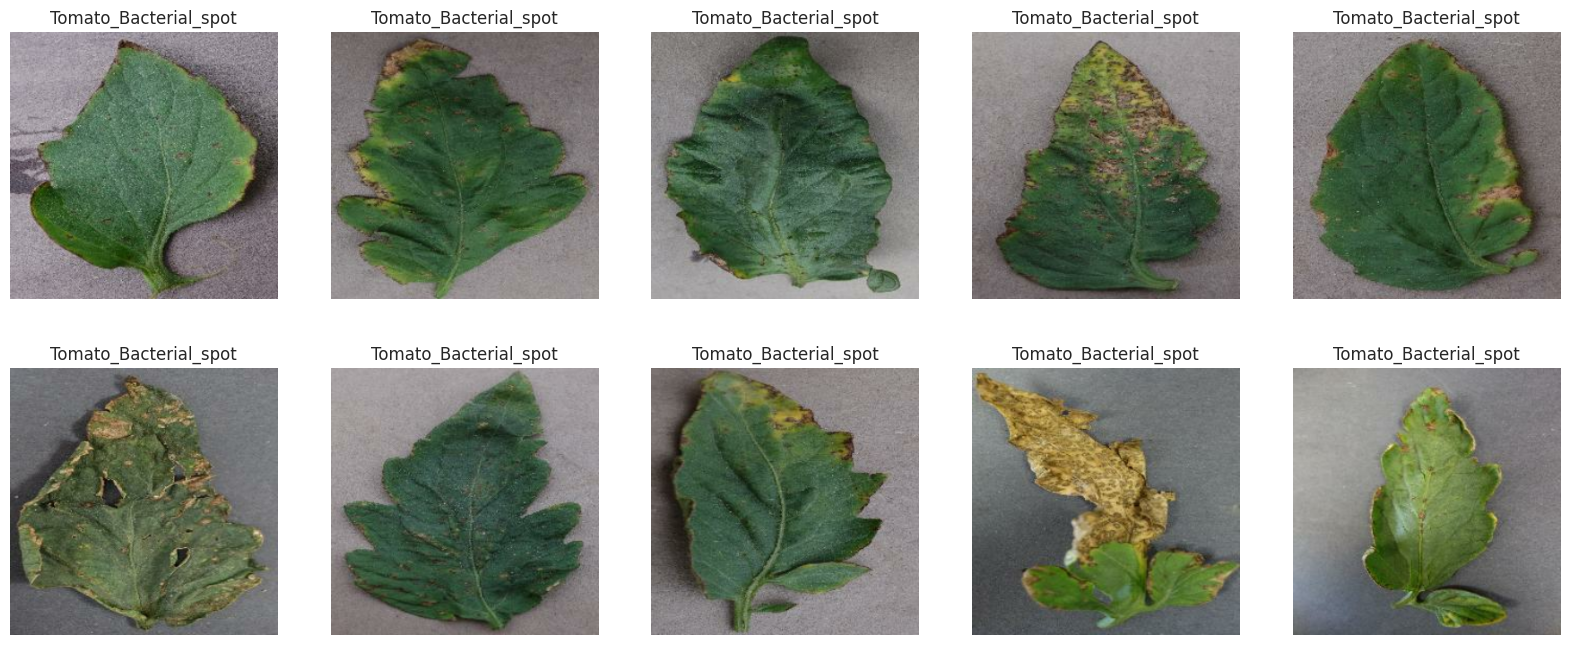

In [15]:
plt.figure(figsize=(20,8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(Tomato_Bacterial_spot[i])
    plt.axis("off")
    plt.title("Tomato_Bacterial_spot")

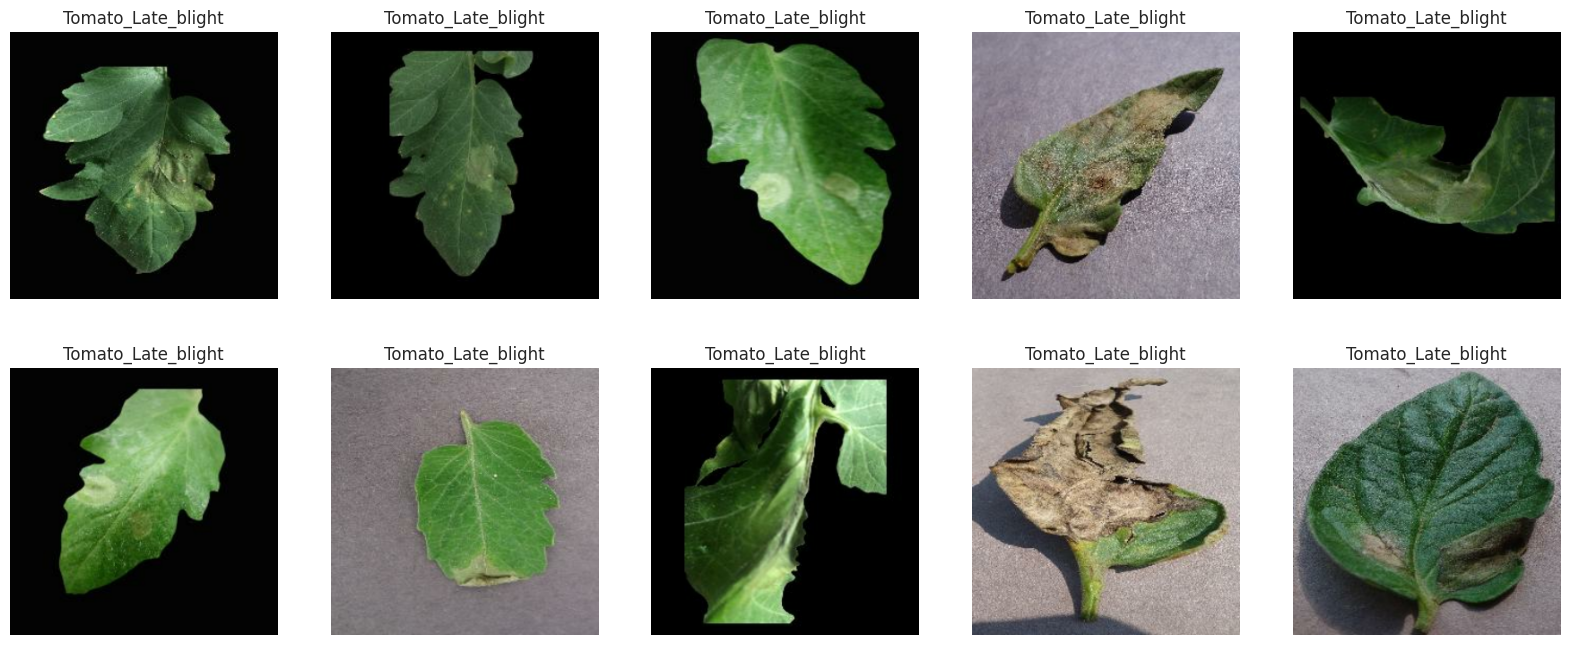

In [16]:
plt.figure(figsize=(20,8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(Tomato_Late_blight[i])
    plt.axis("off")
    plt.title("Tomato_Late_blight")

In [17]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

In [18]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load the VGG19 model (excluding top layers)
base_model = VGG19(input_shape=(299, 299, 3),
                   include_top=False,
                   weights='imagenet')

# Freeze base model layers
base_model.trainable = False

# Build the model
inputs = Input(shape=(299, 299, 3))
x = data_augmentation(inputs)  # Your previously defined augmentation layer
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("vgg19_best_model.h5", save_best_only=True)

80134624/80134624 [==============================] - 0s 0us/step


In [19]:
# Train the model
history = model.fit(train_dataset,
                    validation_data=validation_dataset,
                    epochs=10,
                    class_weight=class_weight,
                    callbacks=[early_stop, checkpoint])

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(validation_dataset)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


Epoch 1/10
50/50 [==============================] - 2430s 48s/step - loss: 4.0662 - accuracy: 0.2640 - val_loss: 1.6486 - val_accuracy: 0.3709
Epoch 2/10
50/50 [==============================] - 2292s 46s/step - loss: 2.5367 - accuracy: 0.3703 - val_loss: 1.0760 - val_accuracy: 0.5487
Epoch 3/10
50/50 [==============================] - 2396s 48s/step - loss: 1.8801 - accuracy: 0.4475 - val_loss: 0.7989 - val_accuracy: 0.6911
Epoch 4/10
50/50 [==============================] - 2434s 49s/step - loss: 1.5429 - accuracy: 0.5196 - val_loss: 0.6377 - val_accuracy: 0.7673
Epoch 5/10
50/50 [==============================] - 2373s 48s/step - loss: 1.2723 - accuracy: 0.5807 - val_loss: 0.5650 - val_accuracy: 0.7884
Epoch 6/10
50/50 [==============================] - 2308s 46s/step - loss: 1.1492 - accuracy: 0.6138 - val_loss: 0.5039 - val_accuracy: 0.8124
Epoch 7/10
50/50 [==============================] - 2377s 48s/step - loss: 1.0078 - accuracy: 0.6597 - val_loss: 0.4668 - val_accuracy: 0.8209

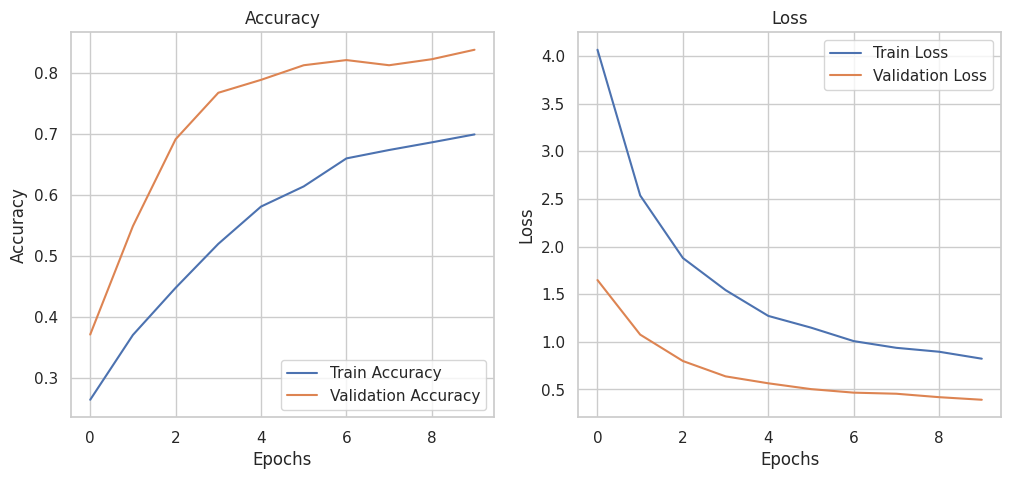

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


3/3 [==============================] - 22s 6s/step


<Figure size 1000x800 with 0 Axes>

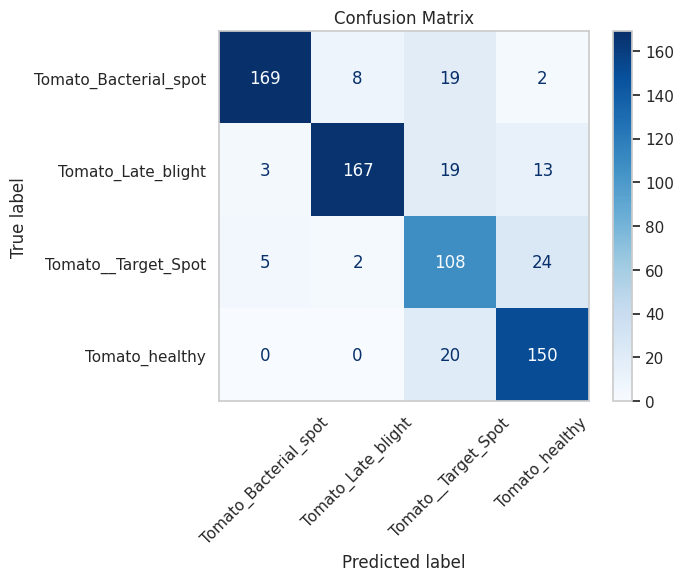

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [22]:
from sklearn.metrics import classification_report

# Ensure predictions and true labels are ready
# (reuse y_true and y_pred from confusion matrix code)

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)


Classification Report:

                       precision    recall  f1-score   support

Tomato_Bacterial_spot       0.95      0.85      0.90       198
   Tomato_Late_blight       0.94      0.83      0.88       202
  Tomato__Target_Spot       0.65      0.78      0.71       139
       Tomato_healthy       0.79      0.88      0.84       170

             accuracy                           0.84       709
            macro avg       0.84      0.83      0.83       709
         weighted avg       0.85      0.84      0.84       709

